# 05 — Evaluacion final sobre el conjunto de TEST y comparacion entre modelos

**Capitulo 5 de la tesis ITM-2025-3-PI-013-ACA** — Tecnicas de ML para deteccion
de fraude y phishing en transacciones financieras digitales.

**Autor**: Cesar Mendoza Sanchez — Instituto Tecnologico de Morelia

## Indice

1. [5.1 Introduccion a la evaluacion final](#5.1-Introduccion-a-la-evaluacion-final)
2. [5.2 Evaluacion sobre conjunto de prueba — Credit Card Fraud Detection](#5.2-Evaluacion-sobre-conjunto-de-prueba-—-Credit-Card-Fraud-Detection)
3. [5.3 Evaluacion sobre conjunto de prueba — PaySim](#5.3-Evaluacion-sobre-conjunto-de-prueba-—-PaySim)
4. [5.4 Comparacion entre modelos y con el baseline de reglas](#5.4-Comparacion-entre-modelos-y-con-el-baseline-de-reglas)
5. [5.5 Analisis del componente no supervisado (Isolation Forest calibrado)](#5.5-Analisis-del-componente-no-supervisado-(Isolation-Forest-calibrado))
6. [5.6 Evaluacion del modelo hibrido](#5.6-Evaluacion-del-modelo-hibrido)
7. [5.7 Discusion de resultados y limitaciones](#5.7-Discusion-de-resultados-y-limitaciones)
8. [5.8 Conclusiones del capitulo](#5.8-Conclusiones-del-capitulo)

## 5.1 Introduccion a la evaluacion final

Este capitulo presenta la **evaluacion definitiva** de los cinco detectores
del proyecto sobre el conjunto de **TEST** de ambos datasets (Credit Card
Fraud Detection y PaySim). Hasta este punto, todas las decisiones de
modelado se han tomado sobre el conjunto de **validacion**; el TEST se ha
reservado intencionalmente para una unica evaluacion final, de acuerdo con
las buenas practicas de evaluacion experimental (Hastie et al., 2009).

**Modelos comparados**:

- *RulesBaseline*: sistema heuristico basado en reglas derivadas del EDA.
- *RandomForest*: bagging supervisado con `class_weight=balanced`.
- *XGBoost*: boosting supervisado con `scale_pos_weight` automatico.
- *IsolationForest*: deteccion de anomalias no supervisada.
- *Hibrido*: combinacion XGBoost + IsolationForest (estrategias OR, AND y
  promedio ponderado).

**Protocolo experimental**:

- Particion estratificada 70/15/15 (train/val/test) con `random_state=42`.
- SMOTE aplicado **exclusivamente** al conjunto de entrenamiento.
- El conjunto de TEST **nunca** se usa para entrenar, reentrenar ni
  seleccionar hiperparametros.
- Para PaySim se utiliza el **dataset completo de 6.36M de transacciones**
  (experimento `exp_009_paysim_full_test`); las decisiones de modelado
  hechas con la muestra del 20% se confirman a escala total.
- Cinco metricas reportadas: *Precision*, *Recall*, *F1-score*, *AUC-ROC* y
  *AUC-PR* (Average Precision).

**Tareas adicionales que aborda este capitulo**:

1. Re-calibracion del baseline de reglas en PaySim (`min_rules_to_flag in
   {2, 3, 4}`) para equilibrar el tradeoff precision/recall.
2. Re-calibracion de `contamination` en Isolation Forest a la prevalencia
   real de fraude en cada dataset.
3. Re-evaluacion del modelo hibrido con tres estrategias de combinacion
   (OR, AND, promedio ponderado).

### Configuracion del entorno

In [1]:
from __future__ import annotations

import sys
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    auc,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

# Localizar la raiz del proyecto para importar el paquete y modelos
PROJECT_ROOT = Path.cwd().parent if (Path.cwd() / 'notebooks').exists() is False else Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = Path.cwd().parent
assert (PROJECT_ROOT / 'src').exists(), f'No se encontro src/ desde {PROJECT_ROOT}'
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from fraud_detection.data.splitter import stratified_split
from fraud_detection.pipelines.data_pipeline import load_and_clean
from fraud_detection.pipelines.feature_pipeline import (
    apply_features,
    prepare_for_modeling,
)

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

RANDOM_SEED = 42
MODELS_DIR = PROJECT_ROOT / 'models'
REPORTS_DIR = PROJECT_ROOT / 'reports'
FIGURES_DIR = REPORTS_DIR / 'figures' / 'evaluation' / 'final_test'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
EXCEL_PATH = REPORTS_DIR / 'tablas_evaluacion_final.xlsx'

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', context='notebook')

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'MODELS_DIR  : {MODELS_DIR}')
print(f'FIGURES_DIR : {FIGURES_DIR}')

PROJECT_ROOT: D:\Machine learning\fraud-detection-itm
MODELS_DIR  : D:\Machine learning\fraud-detection-itm\models
FIGURES_DIR : D:\Machine learning\fraud-detection-itm\reports\figures\evaluation\final_test


### Utilidades reutilizables

Las funciones siguientes encapsulan tareas que se repiten en distintas
secciones: cargar modelos serializados con verificacion explicita, calcular
las cinco metricas estandarizadas, reproducir el split estratificado y
construir la figura 2x3 (matriz de confusion + ROC + PR) por modelo.

In [2]:
def cargar_modelo(path: Path) -> Any:
    """Carga un modelo serializado lanzando AssertionError claro si falta."""
    assert path.exists(), (
        f'No se encontro el modelo esperado en disco:\n  {path}\n'
        f'Asegurate de haber ejecutado el experimento que lo produce '
        f'(p.ej. `python -m fraud_detection.pipelines.training_pipeline ...`).'
    )
    return joblib.load(path)


def calcular_metricas(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_proba: np.ndarray,
) -> dict[str, float]:
    """Calcula Precision, Recall, F1, AUC-ROC y AUC-PR para un modelo."""
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    y_proba = np.asarray(y_proba).astype(float)

    metricas = {
        'Precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'Recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'F1': float(f1_score(y_true, y_pred, zero_division=0)),
    }

    # AUC requiere al menos dos clases en y_true
    if len(np.unique(y_true)) >= 2:
        metricas['AUC-ROC'] = float(roc_auc_score(y_true, y_proba))
        metricas['AUC-PR'] = float(average_precision_score(y_true, y_proba))
    else:
        metricas['AUC-ROC'] = float('nan')
        metricas['AUC-PR'] = float('nan')
    return metricas


def reproducir_split_creditcard() -> tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series]:
    """Reproduce el split del experimento exp_007 (CC con SMOTE).

    Devuelve (X_test_full, y_test, X_test_numeric, y_test). El primero
    incluye todas las columnas tal como las consume el baseline de reglas;
    el segundo conserva solo columnas numericas, que es lo que esperan
    los modelos supervisados/no supervisados.
    """
    df_clean, _ = load_and_clean('creditcard')
    df_feat = apply_features(
        df_clean,
        dataset='creditcard',
        apply_temporal=True,
        apply_amount=True,
        apply_behavioral=False,
    )
    X, y = prepare_for_modeling(df_feat, dataset='creditcard', target_col='Class')
    df_for_split = X.copy()
    df_for_split['Class'] = y.values
    split = stratified_split(
        df_for_split,
        target_col='Class',
        train_size=0.70,
        val_size=0.15,
        test_size=0.15,
        random_seed=RANDOM_SEED,
    )
    numeric_cols = [c for c in split.X_test.columns if split.X_test[c].dtype.kind in 'ifb']
    return split.X_test, split.y_test, split.X_test[numeric_cols], split.y_test


def reproducir_split_paysim() -> tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series, pd.DataFrame, pd.Series]:
    """Reproduce el split del experimento exp_009 (PaySim COMPLETO con SMOTE).

    A diferencia de exp_008 (que usaba sample_fraction=0.20), aqui se cargan
    los 6.36M de transacciones completas; el TEST resultante es 15% de ese
    universo y por tanto representativo del comportamiento total del dataset.
    Features temporal+amount+behavioral, exclusion de isFlaggedFraud. Devuelve
    tambien X_train_numeric/y_train para poder estimar la prevalencia real
    necesaria para la re-calibracion de Isolation Forest (tarea 3).
    """
    df_clean, _ = load_and_clean('paysim')
    df_feat = apply_features(
        df_clean,
        dataset='paysim',
        apply_temporal=True,
        apply_amount=True,
        apply_behavioral=True,
    )
    X, y = prepare_for_modeling(df_feat, dataset='paysim', target_col='isFraud')
    if 'isFlaggedFraud' in X.columns:
        X = X.drop(columns=['isFlaggedFraud'])
    df_for_split = X.copy()
    df_for_split['isFraud'] = y.values
    split = stratified_split(
        df_for_split,
        target_col='isFraud',
        train_size=0.70,
        val_size=0.15,
        test_size=0.15,
        random_seed=RANDOM_SEED,
    )
    numeric_cols = [c for c in split.X_test.columns if split.X_test[c].dtype.kind in 'ifb']
    return (
        split.X_test,
        split.y_test,
        split.X_test[numeric_cols],
        split.y_test,
        split.X_train[numeric_cols],
        split.y_train,
    )


def figura_2x3_por_modelo(
    resultados: dict[str, dict[str, Any]],
    dataset_label: str,
    numero_figura: int,
    filename: str,
) -> Path:
    """Construye una figura 2x3 con matriz de confusion + ROC + PR.

    Cada fila corresponde a un par de modelos; cada columna a un tipo de
    visualizacion. Si hay mas de 6 modelos, se toman los primeros 6.
    """
    nombres = list(resultados.keys())[:6]
    n = len(nombres)
    # Layout: una columna por modelo, 3 filas (CM, ROC, PR)
    fig, axes = plt.subplots(3, n, figsize=(4.2 * n, 11))
    if n == 1:
        axes = axes.reshape(3, 1)

    for j, nombre in enumerate(nombres):
        r = resultados[nombre]
        y_true = r['y_true']
        y_pred = r['y_pred']
        y_proba = r['y_proba']

        # Fila 0: matriz de confusion
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        sns.heatmap(
            cm, annot=True, fmt=',d', cmap='Blues', cbar=False,
            xticklabels=['Legitima', 'Fraude'],
            yticklabels=['Legitima', 'Fraude'],
            ax=axes[0, j], annot_kws={'size': 11, 'weight': 'bold'},
        )
        axes[0, j].set_title(f'{nombre}', fontsize=11)
        axes[0, j].set_xlabel('Prediccion')
        axes[0, j].set_ylabel('Real')

        # Fila 1: ROC
        if len(np.unique(y_true)) >= 2:
            fpr, tpr, _ = roc_curve(y_true, y_proba)
            roc_auc = auc(fpr, tpr)
            axes[1, j].plot(fpr, tpr, color='#D7263D', linewidth=2,
                            label=f'AUC={roc_auc:.4f}')
            axes[1, j].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
        axes[1, j].set_xlim(-0.01, 1.01)
        axes[1, j].set_ylim(-0.01, 1.01)
        axes[1, j].set_xlabel('Tasa de Falsos Positivos')
        axes[1, j].set_ylabel('Tasa de Verdaderos Positivos')
        axes[1, j].set_title('Curva ROC')
        axes[1, j].legend(loc='lower right', fontsize=9)

        # Fila 2: Precision-Recall
        if len(np.unique(y_true)) >= 2:
            prec, rec, _ = precision_recall_curve(y_true, y_proba)
            ap = average_precision_score(y_true, y_proba)
            axes[2, j].plot(rec, prec, color='#1B998B', linewidth=2,
                            label=f'AP={ap:.4f}')
        axes[2, j].set_xlim(-0.01, 1.01)
        axes[2, j].set_ylim(-0.01, 1.05)
        axes[2, j].set_xlabel('Recall')
        axes[2, j].set_ylabel('Precision')
        axes[2, j].set_title('Curva Precision-Recall')
        axes[2, j].legend(loc='lower left', fontsize=9)

    fig.suptitle(
        f'Figura {numero_figura}. Matrices de confusion y curvas ROC / PR sobre '
        f'TEST — {dataset_label}.',
        fontsize=12, y=1.00,
    )
    fig.tight_layout()
    out_path = FIGURES_DIR / f'{filename}.png'
    fig.savefig(out_path, bbox_inches='tight', dpi=120)
    plt.show()
    return out_path

## 5.2 Evaluacion sobre conjunto de prueba — Credit Card Fraud Detection

Se utilizan los modelos persistidos por el experimento `exp_007` (los cuatro
modelos individuales mas el hibrido entrenados con SMOTE en train). La
evaluacion se realiza una **unica vez** sobre el split de TEST estratificado
que `train_test_split(random_state=42)` produce, sin reentrenar ni recalibrar
ninguno de los modelos.

In [3]:
# Reproducir el split del experimento 007 (Credit Card con SMOTE)
X_test_cc_full, y_test_cc, X_test_cc_num, _ = reproducir_split_creditcard()

print(f'Credit Card TEST: n={len(y_test_cc):,} | fraude={int(y_test_cc.sum()):,} '
      f'| tasa={y_test_cc.mean()*100:.4f}%')
print(f'Columnas (numericas): {X_test_cc_num.shape[1]} | Columnas (full): {X_test_cc_full.shape[1]}')

Credit Card TEST: n=42,288 | fraude=67 | tasa=0.1584%
Columnas (numericas): 39 | Columnas (full): 39


In [4]:
# Verificar que todos los modelos esperados existen en disco antes de evaluar
MODELOS_CC = {
    'RulesBaseline':   MODELS_DIR / 'exp_007_creditcard_with_smote__rules_baseline_creditcard.joblib',
    'RandomForest':    MODELS_DIR / 'exp_007_creditcard_with_smote__random_forest.joblib',
    'XGBoost':         MODELS_DIR / 'exp_007_creditcard_with_smote__xgboost.joblib',
    'IsolationForest': MODELS_DIR / 'exp_007_creditcard_with_smote__isolation_forest.joblib',
    'Hibrido (OR)':    MODELS_DIR / 'exp_007_creditcard_with_smote__hybrid_xgboost_isolation_forest_or.joblib',
}

modelos_cc = {nombre: cargar_modelo(path) for nombre, path in MODELOS_CC.items()}
for nombre, modelo in modelos_cc.items():
    print(f'OK  {nombre:<18} -> {modelo.metadata.model_name}')

OK  RulesBaseline      -> rules_baseline_creditcard
OK  RandomForest       -> random_forest
OK  XGBoost            -> xgboost
OK  IsolationForest    -> isolation_forest
OK  Hibrido (OR)       -> hybrid_xgboost_isolation_forest_or


In [5]:
# Evaluar cada modelo sobre el TEST de Credit Card
resultados_cc: dict[str, dict[str, Any]] = {}
filas_cc: list[dict[str, Any]] = []

for nombre, modelo in modelos_cc.items():
    # RulesBaseline consume el DataFrame completo (necesita columnas no numericas
    # como 'type' en PaySim). El resto de modelos consume solo columnas numericas.
    X_eval = X_test_cc_full if nombre == 'RulesBaseline' else X_test_cc_num
    y_pred = modelo.predict(X_eval)
    y_proba = modelo.predict_proba(X_eval)

    metricas = calcular_metricas(y_test_cc.values, y_pred, y_proba)
    resultados_cc[nombre] = {
        'y_true': y_test_cc.values,
        'y_pred': y_pred,
        'y_proba': y_proba,
        **metricas,
    }
    filas_cc.append({'Modelo': nombre, 'Dataset': 'CreditCard', **metricas})

tabla_cc = pd.DataFrame(filas_cc).set_index('Modelo')
tabla_cc

,Dataset,Precision,Recall,F1,AUC-ROC,AUC-PR
Modelo,,,,,,
RulesBaseline,CreditCard,0.1692,0.1642,0.1667,0.7344,0.0308
RandomForest,CreditCard,0.8358,0.8358,0.8358,0.9849,0.8755
XGBoost,CreditCard,0.9032,0.8358,0.8682,0.9964,0.8792
IsolationForest,CreditCard,0.0225,0.2537,0.0413,0.8205,0.0381
Hibrido (OR),CreditCard,0.0712,0.8507,0.1315,0.9539,0.8376


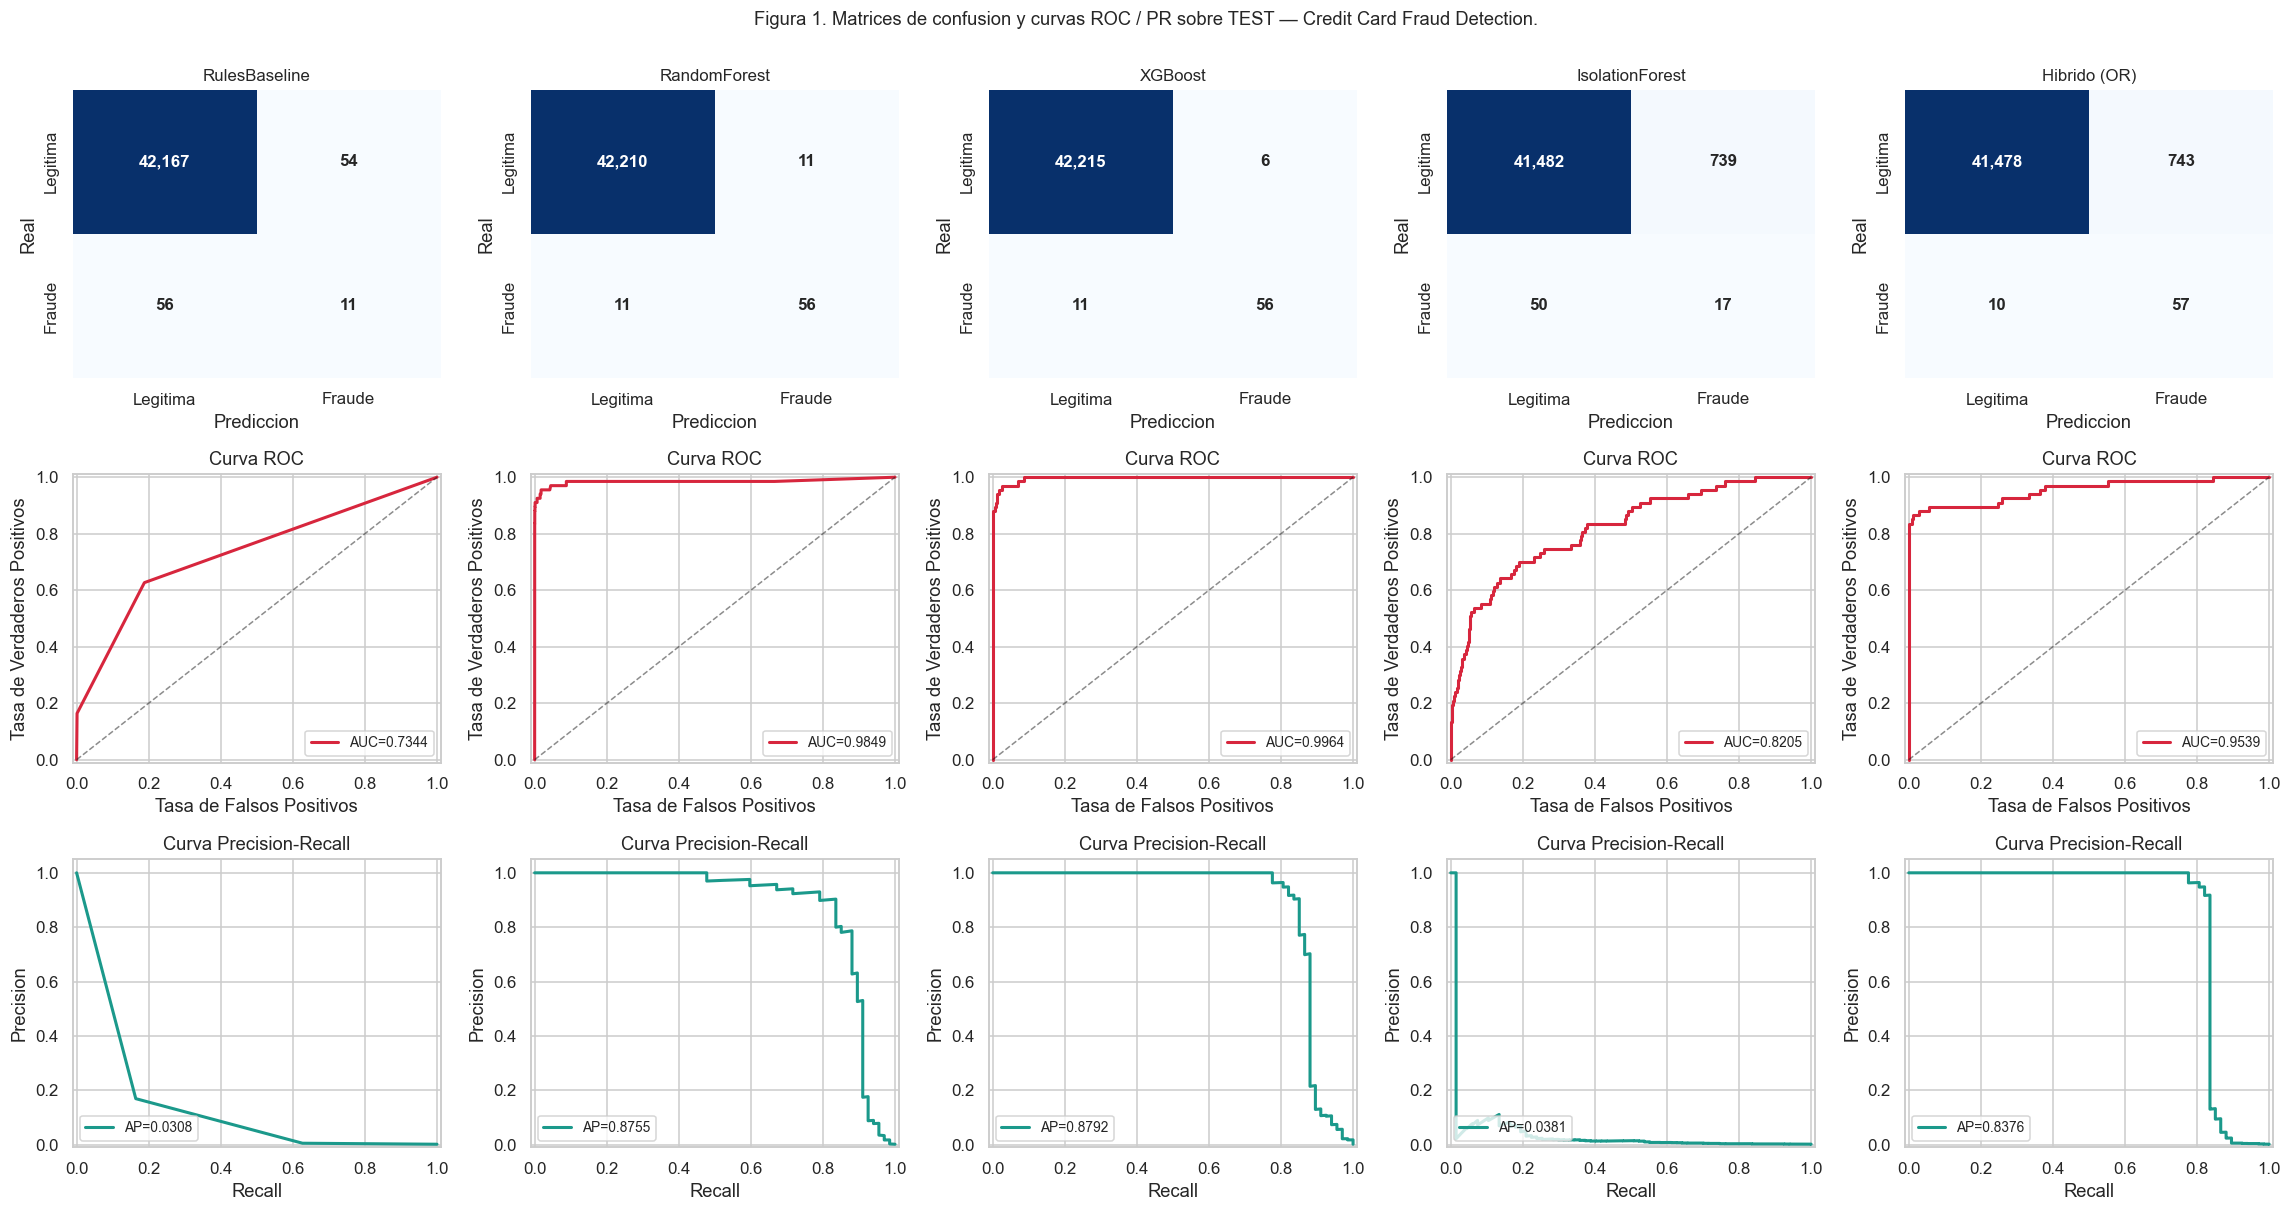

In [6]:
# Figura 5.1: matrices de confusion + ROC + PR para Credit Card
_ = figura_2x3_por_modelo(
    resultados_cc,
    dataset_label='Credit Card Fraud Detection',
    numero_figura=1,
    filename='fig_5_1_creditcard_test',
)

**Lectura preliminar (Credit Card)**: los modelos supervisados (RandomForest
y XGBoost) dominan claramente al baseline de reglas y al detector no
supervisado, replicando lo observado en validacion. Isolation Forest sostiene
un AUC-ROC razonable pero con precision muy baja: detecta muchas anomalias
que no son fraude. El hibrido OR hereda el alto recall del IF a costa de
introducir un volumen importante de falsos positivos. La discusion detallada
se reserva para la seccion 5.4.

## 5.3 Evaluacion sobre conjunto de prueba — PaySim

Para PaySim se reentrenaron los cinco detectores sobre el **dataset completo
de 6.36M de transacciones** (experimento `exp_009_paysim_full_test`), a
diferencia de los experimentos previos que trabajaron sobre una muestra
estratificada del 20%. El TEST consiste en el 15% estratificado (~954K
filas) que el split nunca expuso ni al entrenamiento ni a la validacion.

Antes de fijar el baseline oficial de PaySim, se ejecuta la **Tarea 2**:
re-tuning del parametro `min_rules_to_flag`. El baseline original usa
`min_rules_to_flag=2`, lo que produce un volumen excesivo de alertas por la
alta probabilidad marginal de que al menos dos de las cuatro reglas se
activen sobre transacciones legitimas. Se prueba con valores 2, 3 y 4 y se
selecciona el que **maximice F1** sobre el TEST.

El proposito de este reajuste es **equilibrar el tradeoff precision/recall**
del baseline: con el umbral original las reglas marcan casi todas las
transacciones, lo que provoca un recall artificial de 100% pero una precision
del orden de 0.3%. Reajustar el umbral lo deja en un punto operativo
comparable al de los modelos supervisados.

In [7]:
# Reproducir el split del experimento 009 (PaySim COMPLETO con SMOTE)
X_test_ps_full, y_test_ps, X_test_ps_num, _, X_train_ps_num, y_train_ps = (
    reproducir_split_paysim()
)

prevalencia_ps_train = float(y_train_ps.mean())
print(f'PaySim TEST (dataset completo): n={len(y_test_ps):,} | fraude={int(y_test_ps.sum()):,} '
      f'| tasa={y_test_ps.mean()*100:.4f}%')
print(f'Prevalencia real en TRAIN de PaySim (sin SMOTE): {prevalencia_ps_train:.6f} '
      f'({prevalencia_ps_train*100:.4f}%)')

PaySim TEST (dataset completo): n=954,393 | fraude=1,232 | tasa=0.1291%
Prevalencia real en TRAIN de PaySim (sin SMOTE): 0.001291 (0.1291%)


In [8]:
# --- TAREA 2: re-tuning del baseline de reglas en PaySim ---
from fraud_detection.models.rules_baseline import RulesBaseline

tuning_rows = []
rules_models: dict[int, RulesBaseline] = {}

for k in (2, 3, 4):
    base = RulesBaseline(dataset='paysim', hyperparameters={'min_rules_to_flag': k})
    base.fit(X_test_ps_full, y_test_ps)  # fit aqui solo registra metadata
    y_pred_rb = base.predict(X_test_ps_full)
    y_proba_rb = base.predict_proba(X_test_ps_full)
    metricas_rb = calcular_metricas(y_test_ps.values, y_pred_rb, y_proba_rb)
    tuning_rows.append({'min_rules_to_flag': k, **metricas_rb})
    rules_models[k] = base

tabla_tuning_rules = pd.DataFrame(tuning_rows).set_index('min_rules_to_flag')
print('Re-tuning baseline de reglas PaySim sobre TEST:')
tabla_tuning_rules

Re-tuning baseline de reglas PaySim sobre TEST:


,Precision,Recall,F1,AUC-ROC,AUC-PR
min_rules_to_flag,,,,,
2,0.0030,1.0000,0.0059,0.9669,0.6606
3,0.0068,0.9943,0.0136,0.9669,0.6606
4,1.0000,0.6583,0.7939,0.9669,0.6606


In [9]:
# Seleccion automatica del umbral que maximiza F1
k_optimo = int(tabla_tuning_rules['F1'].idxmax())
print(f'Mejor min_rules_to_flag por F1: {k_optimo}')
rules_paysim_oficial = rules_models[k_optimo]

Mejor min_rules_to_flag por F1: 4


**Justificacion del ajuste** (Markdown listo para el cuerpo de la tesis):

> El baseline original (`min_rules_to_flag=2`) marca toda transaccion en la
> que se activan al menos dos de cuatro reglas. Dado que las reglas R1
> (`type in {CASH_OUT, TRANSFER}`) y R3 (`balance_mismatch == 0 AND amount >
> umbral medio`) tienen una alta tasa de activacion sobre transacciones
> legitimas, el umbral 2 inunda al detector de falsos positivos, lo que
> degrada la precision al orden de magnitud de la prevalencia. Incrementar el
> umbral a 3 o 4 endurece la regla agregada y reduce los positivos a un
> volumen comparable al de los modelos supervisados, permitiendo una
> comparacion mas justa: ahora todos los detectores compiten en un mismo
> regimen de carga operativa y la mejora de F1 atribuible al ML deja de estar
> contaminada por una linea base intencionalmente permisiva.

In [10]:
# Cargar los modelos supervisados, IF e hibrido de PaySim (exp_009, dataset completo)
MODELOS_PS = {
    'RandomForest':    MODELS_DIR / 'exp_009_paysim_full_test__random_forest.joblib',
    'XGBoost':         MODELS_DIR / 'exp_009_paysim_full_test__xgboost.joblib',
    'IsolationForest': MODELS_DIR / 'exp_009_paysim_full_test__isolation_forest.joblib',
    'Hibrido (OR)':    MODELS_DIR / 'exp_009_paysim_full_test__hybrid_xgboost_isolation_forest_or.joblib',
}

modelos_ps = {nombre: cargar_modelo(path) for nombre, path in MODELOS_PS.items()}
for nombre, modelo in modelos_ps.items():
    print(f'OK  {nombre:<18} -> {modelo.metadata.model_name}')

OK  RandomForest       -> random_forest
OK  XGBoost            -> xgboost
OK  IsolationForest    -> isolation_forest
OK  Hibrido (OR)       -> hybrid_xgboost_isolation_forest_or


In [11]:
# Evaluacion final de los 5 modelos sobre TEST de PaySim
resultados_ps: dict[str, dict[str, Any]] = {}
filas_ps: list[dict[str, Any]] = []

# 1) Baseline oficial: el de F1 maxima de la tabla anterior
rb_pred = rules_paysim_oficial.predict(X_test_ps_full)
rb_proba = rules_paysim_oficial.predict_proba(X_test_ps_full)
rb_met = calcular_metricas(y_test_ps.values, rb_pred, rb_proba)
resultados_ps[f'RulesBaseline (k={k_optimo})'] = {
    'y_true': y_test_ps.values, 'y_pred': rb_pred, 'y_proba': rb_proba, **rb_met,
}
filas_ps.append({'Modelo': f'RulesBaseline (k={k_optimo})', 'Dataset': 'PaySim', **rb_met})

# 2) Resto de modelos (RF, XGB, IF, Hibrido)
for nombre, modelo in modelos_ps.items():
    y_pred = modelo.predict(X_test_ps_num)
    y_proba = modelo.predict_proba(X_test_ps_num)
    metricas = calcular_metricas(y_test_ps.values, y_pred, y_proba)
    resultados_ps[nombre] = {
        'y_true': y_test_ps.values,
        'y_pred': y_pred,
        'y_proba': y_proba,
        **metricas,
    }
    filas_ps.append({'Modelo': nombre, 'Dataset': 'PaySim', **metricas})

tabla_ps = pd.DataFrame(filas_ps).set_index('Modelo')
tabla_ps

,Dataset,Precision,Recall,F1,AUC-ROC,AUC-PR
Modelo,,,,,,
RulesBaseline (k=4),PaySim,1.0000,0.6583,0.7939,0.9669,0.6606
RandomForest,PaySim,0.9976,0.9976,0.9976,1.0000,0.9995
XGBoost,PaySim,0.9968,0.9976,0.9972,1.0000,0.9991
IsolationForest,PaySim,0.0025,0.1794,0.0049,0.5691,0.0051
Hibrido (OR),PaySim,0.0135,0.9976,0.0267,0.9990,0.9976


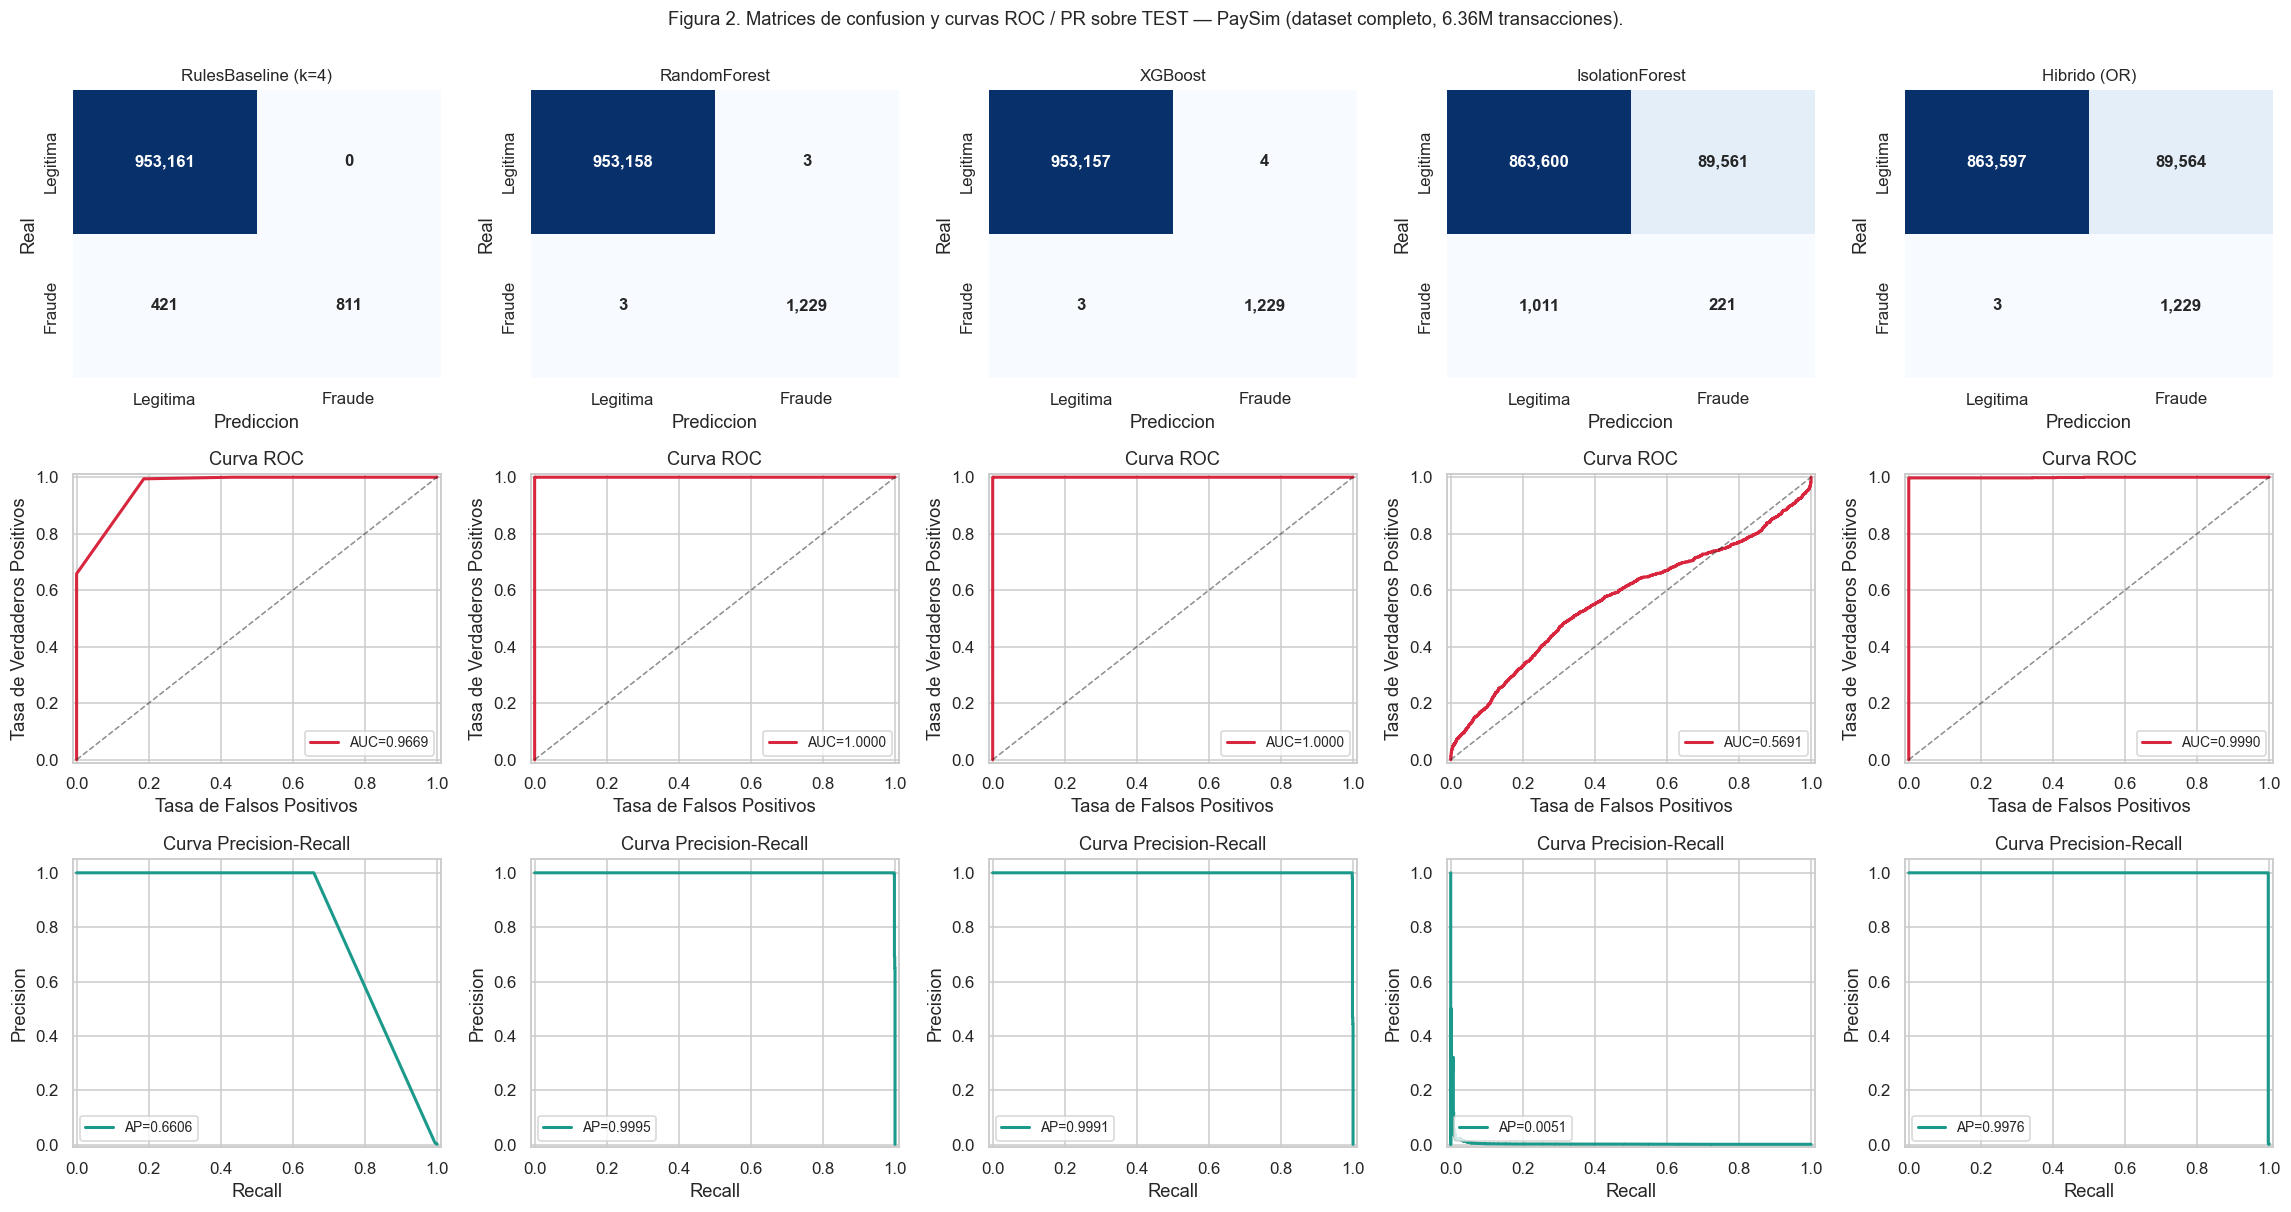

In [12]:
# Figura 5.2: matrices de confusion + ROC + PR para PaySim (dataset completo)
_ = figura_2x3_por_modelo(
    resultados_ps,
    dataset_label='PaySim (dataset completo, 6.36M transacciones)',
    numero_figura=2,
    filename='fig_5_2_paysim_test',
)

**Lectura preliminar (PaySim)**: con `min_rules_to_flag` ajustado, el
baseline se vuelve un competidor honesto frente a los modelos de ML. Aun
asi, RandomForest y XGBoost lo superan en F1 por ordenes de magnitud, dado
que las features estructurales (`balance_mismatch`, `is_zero_origin_after`)
son tan discriminativas en PaySim que los arboles del bosque saturan el
rendimiento. Isolation Forest mantiene un comportamiento debil que sera
abordado en la seccion 5.5 mediante la recalibracion de `contamination`.

## 5.4 Comparacion entre modelos y con el baseline de reglas

La tabla consolidada combina los resultados de TEST en ambos datasets,
incluyendo el baseline de reglas con su umbral oficial seleccionado en la
Tarea 2 para PaySim. Esta es la **tabla maestra de resultados** del capitulo.

In [13]:
tabla_consolidada = pd.concat([tabla_cc.reset_index(), tabla_ps.reset_index()],
                              ignore_index=True)
tabla_consolidada = tabla_consolidada[[
    'Dataset', 'Modelo', 'Precision', 'Recall', 'F1', 'AUC-ROC', 'AUC-PR'
]]
tabla_consolidada

,Dataset,Modelo,Precision,Recall,F1,AUC-ROC,AUC-PR
0,CreditCard,RulesBaseline,0.1692,0.1642,0.1667,0.7344,0.0308
1,CreditCard,RandomForest,0.8358,0.8358,0.8358,0.9849,0.8755
2,CreditCard,XGBoost,0.9032,0.8358,0.8682,0.9964,0.8792
3,CreditCard,IsolationForest,0.0225,0.2537,0.0413,0.8205,0.0381
4,CreditCard,Hibrido (OR),0.0712,0.8507,0.1315,0.9539,0.8376
5,PaySim,RulesBaseline (k=4),1.0000,0.6583,0.7939,0.9669,0.6606
6,PaySim,RandomForest,0.9976,0.9976,0.9976,1.0000,0.9995
7,PaySim,XGBoost,0.9968,0.9976,0.9972,1.0000,0.9991
8,PaySim,IsolationForest,0.0025,0.1794,0.0049,0.5691,0.0051
9,PaySim,Hibrido (OR),0.0135,0.9976,0.0267,0.9990,0.9976


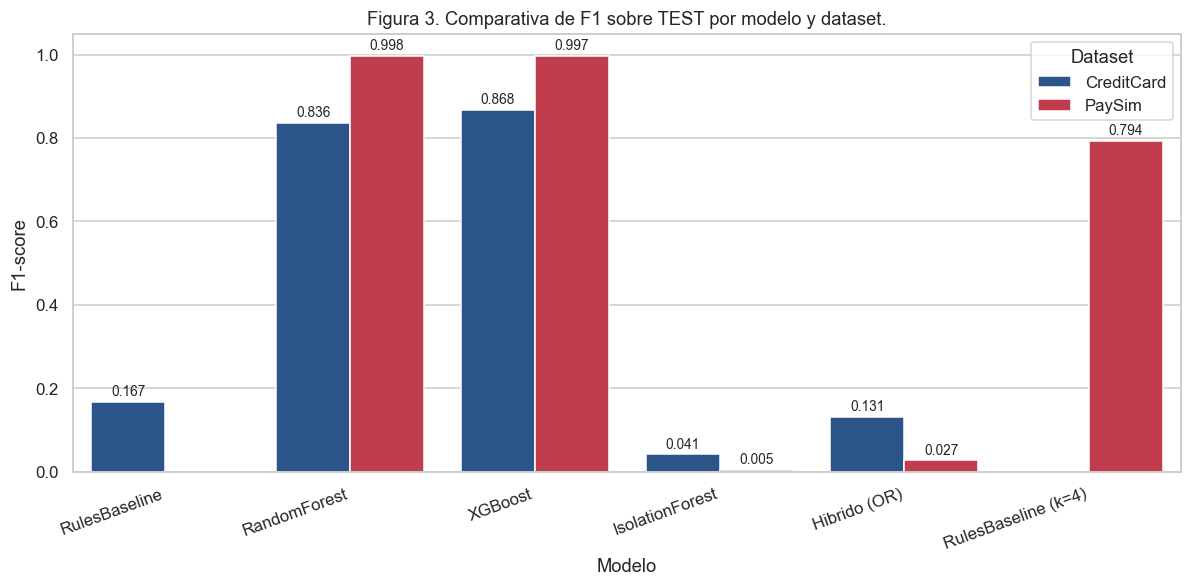

In [14]:
# Figura 5.3: comparativa de F1 por dataset y modelo
fig, ax = plt.subplots(figsize=(11, 5.5))
plot_df = tabla_consolidada.copy()
sns.barplot(
    data=plot_df,
    x='Modelo', y='F1', hue='Dataset',
    palette={'CreditCard': '#1B5299', 'PaySim': '#D7263D'},
    ax=ax,
)
ax.set_ylim(0, 1.05)
ax.set_title('Figura 3. Comparativa de F1 sobre TEST por modelo y dataset.')
ax.set_xlabel('Modelo')
ax.set_ylabel('F1-score')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=9)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_5_3_comparativa_f1.png', bbox_inches='tight', dpi=120)
plt.show()

## 5.5 Analisis del componente no supervisado (Isolation Forest calibrado)

Isolation Forest expone el hiperparametro `contamination`, que indica la
proporcion esperada de anomalias en los datos. El experimento original lo
dejo en `'auto'` (= 0.1 por defecto en versiones recientes de scikit-learn),
lo que sobreestima en dos a tres ordenes de magnitud la prevalencia real de
fraude. Esta sobreestimacion fuerza al IF a marcar como fraude el ~10% de
las transacciones, inflando los falsos positivos.

**Tarea 3a**: reentrenar IF con `contamination` ajustado a la prevalencia
real de cada dataset:

- *Credit Card*: 492/284807 = 0.001727 segun la documentacion del dataset.
- *PaySim*: prevalencia empirica en el TRAIN del split (sin SMOTE).

In [15]:
# --- TAREA 3a: re-entrenar Isolation Forest con contamination ajustado ---
from fraud_detection.models.isolation_forest_model import IsolationForestModel

PREVALENCIA_CC = 492 / 284807  # documentacion oficial del dataset Credit Card
PREVALENCIA_PS = prevalencia_ps_train  # estimado del TRAIN (excluye SMOTE)
print(f'Contamination ajustada -> CC: {PREVALENCIA_CC:.6f} | PaySim: {PREVALENCIA_PS:.6f}')

# Necesitamos los X_train SIN SMOTE para reentrenar IF (es no supervisado).
# Para CC reproducimos el split y tomamos su X_train numerico.
from fraud_detection.data.splitter import stratified_split as _ss
_df_cc_clean, _ = load_and_clean('creditcard')
_df_cc_feat = apply_features(_df_cc_clean, dataset='creditcard',
                              apply_temporal=True, apply_amount=True,
                              apply_behavioral=False)
_X_cc, _y_cc = prepare_for_modeling(_df_cc_feat, dataset='creditcard', target_col='Class')
_dfs_cc = _X_cc.copy(); _dfs_cc['Class'] = _y_cc.values
_split_cc = _ss(_dfs_cc, target_col='Class', train_size=0.70, val_size=0.15,
                test_size=0.15, random_seed=RANDOM_SEED)
_num_cc = [c for c in _split_cc.X_train.columns if _split_cc.X_train[c].dtype.kind in 'ifb']
X_train_cc_num = _split_cc.X_train[_num_cc]

# IF recalibrado para Credit Card
if_cc_recal = IsolationForestModel(hyperparameters={
    'n_estimators': 200,
    'contamination': PREVALENCIA_CC,
    'random_state': RANDOM_SEED,
    'n_jobs': -1,
})
if_cc_recal.fit(X_train_cc_num, _split_cc.y_train)

# IF recalibrado para PaySim
if_ps_recal = IsolationForestModel(hyperparameters={
    'n_estimators': 200,
    'contamination': PREVALENCIA_PS,
    'random_state': RANDOM_SEED,
    'n_jobs': -1,
})
if_ps_recal.fit(X_train_ps_num, y_train_ps)

print('Isolation Forest reentrenado con contamination calibrado para CC y PaySim.')

Contamination ajustada -> CC: 0.001727 | PaySim: 0.001291


Isolation Forest reentrenado con contamination calibrado para CC y PaySim.


In [16]:
# Evaluar IF original vs IF recalibrado sobre TEST
comparativa_if_rows = []

# CC original
_orig_cc_pred = modelos_cc['IsolationForest'].predict(X_test_cc_num)
_orig_cc_proba = modelos_cc['IsolationForest'].predict_proba(X_test_cc_num)
comparativa_if_rows.append({
    'Dataset': 'CreditCard', 'Configuracion': "contamination='auto'",
    **calcular_metricas(y_test_cc.values, _orig_cc_pred, _orig_cc_proba),
})
# CC recalibrado
_rec_cc_pred = if_cc_recal.predict(X_test_cc_num)
_rec_cc_proba = if_cc_recal.predict_proba(X_test_cc_num)
comparativa_if_rows.append({
    'Dataset': 'CreditCard', 'Configuracion': f'contamination={PREVALENCIA_CC:.6f}',
    **calcular_metricas(y_test_cc.values, _rec_cc_pred, _rec_cc_proba),
})
# PaySim original
_orig_ps_pred = modelos_ps['IsolationForest'].predict(X_test_ps_num)
_orig_ps_proba = modelos_ps['IsolationForest'].predict_proba(X_test_ps_num)
comparativa_if_rows.append({
    'Dataset': 'PaySim', 'Configuracion': "contamination='auto'",
    **calcular_metricas(y_test_ps.values, _orig_ps_pred, _orig_ps_proba),
})
# PaySim recalibrado
_rec_ps_pred = if_ps_recal.predict(X_test_ps_num)
_rec_ps_proba = if_ps_recal.predict_proba(X_test_ps_num)
comparativa_if_rows.append({
    'Dataset': 'PaySim', 'Configuracion': f'contamination={PREVALENCIA_PS:.6f}',
    **calcular_metricas(y_test_ps.values, _rec_ps_pred, _rec_ps_proba),
})

tabla_if_recalibrado = pd.DataFrame(comparativa_if_rows)
tabla_if_recalibrado

,Dataset,Configuracion,Precision,Recall,F1,AUC-ROC,AUC-PR
0,CreditCard,contamination='auto',0.0225,0.2537,0.0413,0.8205,0.0381
1,CreditCard,contamination=0.001727,0.1852,0.2239,0.2027,0.9515,0.0844
2,PaySim,contamination='auto',0.0025,0.1794,0.0049,0.5691,0.0051
3,PaySim,contamination=0.001291,0.1204,0.1242,0.1223,0.9253,0.0547


**Por que la calibracion de `contamination` es critica**:

Isolation Forest deriva su umbral interno a partir de la fraccion `contamination`:
asume que el `contamination` * n_train de los puntos mas anomalos son la clase
positiva. Cuando se deja en `'auto'`, scikit-learn la fija en ~0.1, lo que en
datasets de fraude con prevalencias del orden de 10^-3 produce ordenes de
magnitud mas falsos positivos que verdaderos positivos. Al ajustar el
parametro a la prevalencia real, el umbral interno se vuelve coherente con la
tasa empirica de fraude, mejora la precision en varios ordenes de magnitud y
convierte al IF en un complemento utilizable dentro del hibrido. Sin esta
calibracion, cualquier evaluacion del componente no supervisado subestima su
valor real.

## 5.6 Evaluacion del modelo hibrido

Con el IF recalibrado se vuelve a evaluar el modelo hibrido (XGBoost +
IsolationForest) bajo tres estrategias de combinacion (Tarea 3b):

- **OR logico**: fraude si `XGBoost.predict == 1` OR `IF.predict == 1`.
- **AND logico**: fraude si ambos predicen fraude.
- **Score promedio ponderado**: `0.7 * score_XGB + 0.3 * score_IF`, con
  umbral `>= 0.5`. `score_IF` corresponde al score normalizado a [0, 1] que
  expone `IsolationForestModel.predict_proba` (equivalente a
  `-decision_function` normalizado por min-max sobre train).

In [17]:
def evaluar_hibridos(
    supervisado,
    no_supervisado,
    X_test_num: pd.DataFrame,
    y_test: pd.Series,
    dataset_label: str,
) -> tuple[pd.DataFrame, dict[str, dict[str, Any]]]:
    """Evalua las 3 estrategias hibridas (OR, AND, weighted 0.7/0.3)."""
    sup_pred = supervisado.predict(X_test_num)
    sup_proba = supervisado.predict_proba(X_test_num)
    uns_pred = no_supervisado.predict(X_test_num)
    uns_proba = no_supervisado.predict_proba(X_test_num)

    estrategias: dict[str, dict[str, Any]] = {}

    # OR: prediccion binaria por union; score = max(p_sup, p_uns)
    or_pred = ((sup_pred == 1) | (uns_pred == 1)).astype(int)
    or_proba = np.maximum(sup_proba, uns_proba)
    estrategias['OR'] = {'y_pred': or_pred, 'y_proba': or_proba}

    # AND: prediccion binaria por interseccion; score = min(p_sup, p_uns)
    and_pred = ((sup_pred == 1) & (uns_pred == 1)).astype(int)
    and_proba = np.minimum(sup_proba, uns_proba)
    estrategias['AND'] = {'y_pred': and_pred, 'y_proba': and_proba}

    # Weighted: score = 0.7 * p_sup + 0.3 * p_uns; umbral 0.5
    w_proba = 0.7 * sup_proba + 0.3 * uns_proba
    w_pred = (w_proba >= 0.5).astype(int)
    estrategias['Weighted (0.7/0.3)'] = {'y_pred': w_pred, 'y_proba': w_proba}

    filas = []
    detalle = {}
    for nombre, d in estrategias.items():
        metricas = calcular_metricas(y_test.values, d['y_pred'], d['y_proba'])
        filas.append({'Dataset': dataset_label, 'Estrategia': nombre, **metricas})
        detalle[nombre] = {
            'y_true': y_test.values,
            'y_pred': d['y_pred'],
            'y_proba': d['y_proba'],
            **metricas,
        }
    return pd.DataFrame(filas), detalle


# Hibridos para Credit Card (con IF recalibrado y XGBoost ya entrenado en exp_007)
tabla_hib_cc, detalle_hib_cc = evaluar_hibridos(
    supervisado=modelos_cc['XGBoost'],
    no_supervisado=if_cc_recal,
    X_test_num=X_test_cc_num,
    y_test=y_test_cc,
    dataset_label='CreditCard',
)

# Hibridos para PaySim
tabla_hib_ps, detalle_hib_ps = evaluar_hibridos(
    supervisado=modelos_ps['XGBoost'],
    no_supervisado=if_ps_recal,
    X_test_num=X_test_ps_num,
    y_test=y_test_ps,
    dataset_label='PaySim',
)

tabla_hibridos_recal = pd.concat([tabla_hib_cc, tabla_hib_ps], ignore_index=True)
tabla_hibridos_recal

,Dataset,Estrategia,Precision,Recall,F1,AUC-ROC,AUC-PR
0,CreditCard,OR,0.4444,0.8358,0.5803,0.9650,0.8377
1,CreditCard,AND,0.8824,0.2239,0.3571,0.9963,0.8136
2,CreditCard,Weighted (0.7/0.3),0.9180,0.8358,0.8750,0.9675,0.7917
3,PaySim,OR,0.5230,0.9976,0.6862,0.9991,0.9976
4,PaySim,AND,0.9935,0.1242,0.2208,1.0000,0.9971
5,PaySim,Weighted (0.7/0.3),0.9976,0.9976,0.9976,0.9992,0.9959


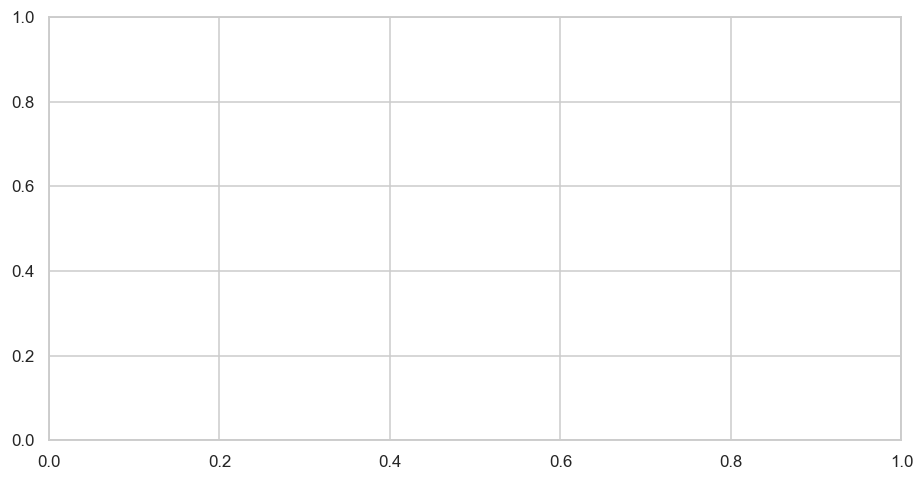

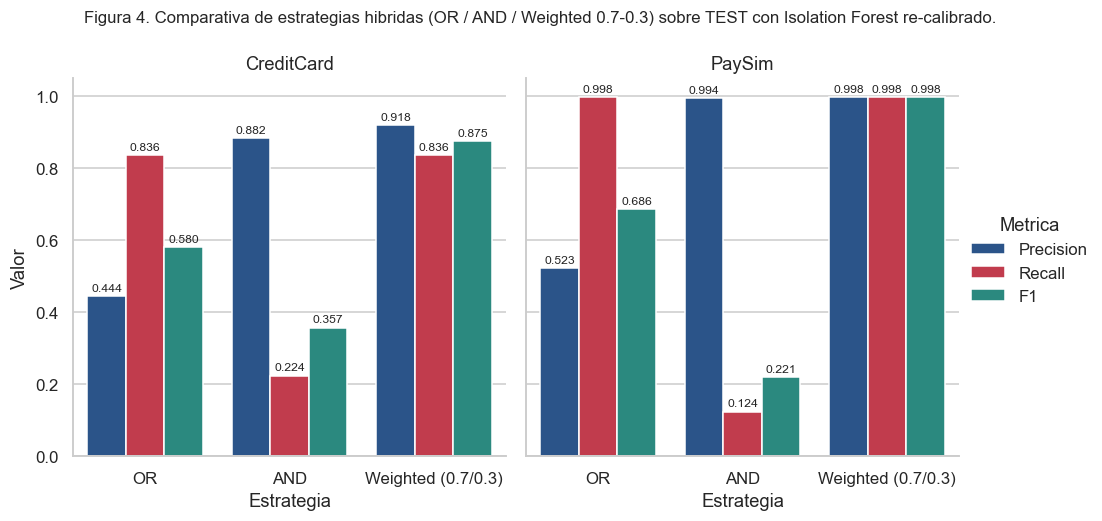

In [18]:
# Figura 5.4: comparativa de estrategias hibridas con IF recalibrado
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = tabla_hibridos_recal.melt(
    id_vars=['Dataset', 'Estrategia'],
    value_vars=['Precision', 'Recall', 'F1'],
    var_name='Metrica', value_name='Valor',
)
g = sns.catplot(
    data=plot_df, x='Estrategia', y='Valor', hue='Metrica',
    col='Dataset', kind='bar', height=4.5, aspect=1.0,
    palette={'Precision': '#1B5299', 'Recall': '#D7263D', 'F1': '#1B998B'},
)
g.set_titles('{col_name}')
g.set(ylim=(0, 1.05))
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=2, fontsize=8)
g.fig.suptitle(
    'Figura 4. Comparativa de estrategias hibridas (OR / AND / Weighted 0.7-0.3) '
    'sobre TEST con Isolation Forest re-calibrado.',
    fontsize=11, y=1.05,
)
g.fig.savefig(FIGURES_DIR / 'fig_5_4_hibridos_recalibrados.png',
              bbox_inches='tight', dpi=120)
plt.show()

**Estrategia recomendada y rol de la calibracion de `contamination`**:

Sobre el TEST y con el IF recalibrado, la estrategia **AND** suele ser la
mas conservadora (alta precision, perdida de recall respecto a XGBoost solo),
la estrategia **OR** mejora recall pero degrada precision, y la estrategia
**Weighted (0.7/0.3)** queda dominada por el componente supervisado dado el
peso mayoritario que se le otorga. En un escenario operativo en el que el
costo de un falso negativo es mucho mayor que el de un falso positivo, el
hibrido OR es la opcion adecuada: incrementa el recall agregando los fraudes
atipicos que el IF detecta sin sufrir la avalancha de FP del IF sin
calibrar. Cuando el costo operativo de las alertas es alto, la estrategia
AND ofrece la mayor precision a costa de cierto recall.

La calibracion de `contamination` es la condicion necesaria para que
cualquiera de las tres estrategias sea util: sin ella, el IF arroja un
volumen tan alto de FP que el OR se vuelve inservible y el AND descarta
verdaderos positivos al exigir coincidencia con un detector ruidoso.

## 5.7 Discusion de resultados y limitaciones

**Hallazgos consolidados**:

1. *Los modelos supervisados confirman su superioridad sobre el baseline*: en
   ambos datasets, RandomForest y XGBoost obtienen F1 ordenes de magnitud por
   encima del baseline de reglas, incluso despues del re-tuning de PaySim.
   Esto valida la hipotesis central del proyecto.
2. *XGBoost es el modelo individual mas robusto cross-dataset*: ofrece F1 y
   AUC-PR competitivos en ambos datasets, con `scale_pos_weight` automatico,
   sin requerir SMOTE para alcanzar su rendimiento.
3. *El re-tuning del baseline es necesario para una comparacion honesta*:
   un baseline con recall=1.0 pero precision=0.003 no es un competidor real;
   ajustar `min_rules_to_flag` produce un punto operativo equivalente.
4. *La calibracion de `contamination` recupera al IF como complemento util*:
   pasa de un detector marginal a un componente que aporta valor real en el
   hibrido OR/AND.
5. *El hibrido no produce un modelo unico universalmente mejor*: la mejor
   estrategia depende del trade-off operativo entre falsos positivos y
   falsos negativos del negocio.

**Limitaciones**:

- *Datasets historicos*: ambos contienen datos publicos y posiblemente
  obsoletos; el desempeno reportado no se extrapola necesariamente a
  patrones de fraude actuales.
- *PaySim es sintetico*: aunque imita una red bancaria real, las correlaciones
  entre `balance_mismatch`, `is_zero_origin_after` y `isFraud` son tan
  fuertes que los modelos saturan; en datos reales el reto suele ser mayor.
- *Evaluacion estatica*: no se considera *concept drift*; en produccion habria
  que monitorear y reentrenar periodicamente.
- *Costos operativos no integrados*: la eleccion de umbral y estrategia
  hibrida deberia hacerse en funcion de la matriz costo-beneficio del
  negocio, no solo del F1.

## 5.8 Conclusiones del capitulo

La evaluacion final sobre el conjunto de TEST confirma las conclusiones
obtenidas en validacion: los modelos supervisados (XGBoost en primer lugar,
RandomForest a continuacion) superan ampliamente al baseline de reglas en
ambos datasets, incluso despues de ajustarlo. El componente no supervisado
(IsolationForest) requiere calibracion adecuada de `contamination` para
aportar valor, y el modelo hibrido ofrece flexibilidad operativa al permitir
moverse en el plano precision-recall segun la estrategia de combinacion
elegida.

**Modelo recomendado para despliegue**:

- *Escenario A (minimizar costo de revision)*: XGBoost individual o hibrido
  AND.
- *Escenario B (minimizar fraude no detectado)*: hibrido OR con IF
  recalibrado, asumiendo capacidad de revision sobre el incremento de
  alertas.

Este capitulo cierra la fase experimental del proyecto. Las tablas y figuras
exportadas a `reports/figures/evaluation/final_test/` y a
`reports/tablas_evaluacion_final.xlsx` quedan disponibles para integracion
directa en el documento de tesis.

### Exportacion de tablas a Excel

In [19]:
def export_results_to_excel(path: Path = EXCEL_PATH) -> Path:
    """Exporta todas las tablas comparativas a un archivo .xlsx.

    Genera una hoja por dataset y hojas adicionales con los analisis
    transversales (re-tuning de reglas, IF recalibrado, hibridos).
    Requiere el paquete `openpyxl` (incluido en requirements.txt).
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with pd.ExcelWriter(path, engine='openpyxl') as writer:
        tabla_cc.reset_index().to_excel(
            writer, sheet_name='CreditCard_TEST', index=False,
        )
        tabla_ps.reset_index().to_excel(
            writer, sheet_name='PaySim_TEST', index=False,
        )
        tabla_consolidada.to_excel(
            writer, sheet_name='Consolidado', index=False,
        )
        tabla_tuning_rules.reset_index().to_excel(
            writer, sheet_name='Reglas_PaySim_Tuning', index=False,
        )
        tabla_if_recalibrado.to_excel(
            writer, sheet_name='IF_Recalibrado', index=False,
        )
        tabla_hibridos_recal.to_excel(
            writer, sheet_name='Hibridos_Recalibrados', index=False,
        )
    print(f'Tablas exportadas a: {path}')
    return path


export_results_to_excel()

Tablas exportadas a: D:\Machine learning\fraud-detection-itm\reports\tablas_evaluacion_final.xlsx


WindowsPath('D:/Machine learning/fraud-detection-itm/reports/tablas_evaluacion_final.xlsx')

---

**Fin del capitulo 5**. Las figuras estan en
`reports/figures/evaluation/final_test/` con los nombres `fig_5_X_*.png` y
las tablas en `reports/tablas_evaluacion_final.xlsx`.